In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

Dataset:

   Hours  Scores
0      2      35
1      4      40
2      6      50
3      8      55
4     10      60
5     12      70
6     14      75
7     16      80
8     18      85
9     20      95



Enter Study Hours:  15



Predicted Score: 78.1
Grade: B


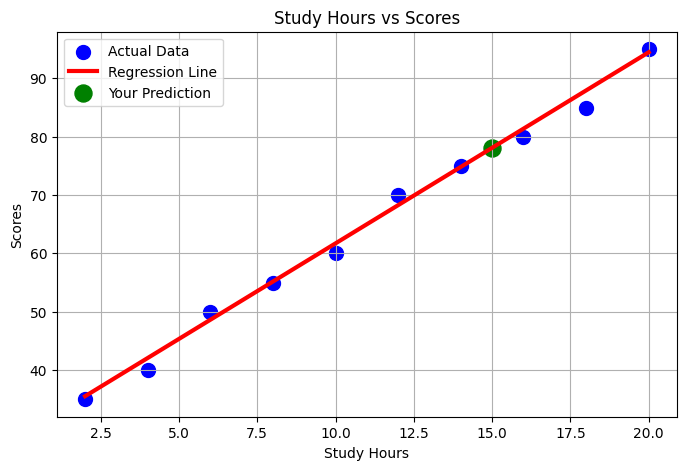

In [19]:
# STUDENT SCORE PREDICTION BASED ON STUDY HOURS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Create dataset
hours = np.array([2, 4, 6, 8, 10, 12, 14, 16, 18, 20])
scores = np.array([35, 40, 50, 55, 60, 70, 75, 80, 85, 95])

# Create DataFrame
df = pd.DataFrame({
    "Hours": hours,
    "Scores": scores
})

print("Dataset:\n")
print(df)

# Input and Output
X = df[["Hours"]]
y = df["Scores"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create and train model
model = LinearRegression()
model.fit(X_train, y_train)

# User input
study_hours = float(input("\nEnter Study Hours: "))

# Predict score
predicted_score = model.predict(
    pd.DataFrame([[study_hours]], columns=['Hours'])
)[0]

# Grade function
def get_grade(score):
    if score >= 80:
        return "A"
    elif score >= 70:
        return "B"
    elif score >= 60:
        return "C"
    elif score >= 50:
        return "D"
    else:
        return "F"

# Print prediction
print("\nPredicted Score:", round(predicted_score, 2))
print("Grade:", get_grade(predicted_score))

# Graph
plt.figure(figsize=(8,5))

# Actual data points
plt.scatter(hours, scores,
            color='blue',
            s=100,
            label='Actual Data')

# Regression line
plt.plot(hours,
         model.predict(X),
         color='red',
         linewidth=3,
         label='Regression Line')

# User prediction point
plt.scatter(study_hours,
            predicted_score,
            color='green',
            s=150,
            label='Your Prediction')

# Labels and title
plt.xlabel("Study Hours")
plt.ylabel("Scores")
plt.title("Study Hours vs Scores")

plt.legend()
plt.grid()
plt.show()